In [1]:
import os
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.datasets import fetch_lfw_people
import numpy as np


KNOWN_DIR = "known_faces"
TEST_DIR = "test_images"

PEOPLE_COUNT = 5
TEST_IMAGES_PER_PERSON = 3
UNKNOWN_COUNT = 3


def save_image(image_array, path):
    if image_array.max() <= 1.0:
        image_array = image_array * 255

    image_array = np.clip(image_array, 0, 255).astype(np.uint8)

    image = Image.fromarray(image_array)
    image.save(path)


def prepare_dataset():
    os.makedirs(KNOWN_DIR, exist_ok=True)
    os.makedirs(TEST_DIR, exist_ok=True)

    print("Загрузка LFW...")

    lfw = fetch_lfw_people(
        min_faces_per_person=10,
        resize=1.0,
        color=True,
    )

    images = lfw.images
    labels = lfw.target
    names = lfw.target_names

    print(f"Всего изображений: {len(images)}")
    print(f"Всего людей: {len(names)}")

    known_labels = list(range(PEOPLE_COUNT))

    print("\nИзвестные люди:")

    for label in known_labels:
        person_name = names[label]
        person_indices = [
            i
            for i, current_label in enumerate(labels)
            if current_label == label
        ]

        print(f"- {person_name}: {len(person_indices)} фото")

        known_image = images[person_indices[0]]

        known_path = os.path.join(
            KNOWN_DIR,
            f"{person_name.replace(' ', '_')}.jpg",
        )

        save_image(
            known_image,
            known_path,
        )

        for test_index in range(TEST_IMAGES_PER_PERSON):
            image = images[
                person_indices[test_index + 1]
            ]

            test_path = os.path.join(
                TEST_DIR,
                (
                    f"{person_name.replace(' ', '_')}"
                    f"_test_{test_index + 1}.jpg"
                ),
            )

            save_image(
                image,
                test_path,
            )

    print("\nНеизвестные люди:")

    unknown_labels = range(
        PEOPLE_COUNT,
        PEOPLE_COUNT + UNKNOWN_COUNT,
    )

    for number, label in enumerate(
        unknown_labels,
        start=1,
    ):
        person_name = names[label]

        person_indices = [
            i
            for i, current_label in enumerate(labels)
            if current_label == label
        ]

        image = images[person_indices[0]]

        path = os.path.join(
            TEST_DIR,
            f"unknown_{number}.jpg",
        )

        save_image(
            image,
            path,
        )

        print(f"- {person_name} -> unknown_{number}.jpg")

    print("\nГотово.")
    print(f"Известные лица: {KNOWN_DIR}")
    print(f"Тестовые изображения: {TEST_DIR}")


if __name__ == "__main__":
    prepare_dataset()

Загрузка LFW...
Всего изображений: 4324
Всего людей: 158

Известные люди:
- Abdullah Gul: 19 фото
- Adrien Brody: 12 фото
- Alejandro Toledo: 39 фото
- Alvaro Uribe: 35 фото
- Amelie Mauresmo: 21 фото

Неизвестные люди:
- Andre Agassi -> unknown_1.jpg
- Andy Roddick -> unknown_2.jpg
- Angelina Jolie -> unknown_3.jpg

Готово.
Известные лица: known_faces
Тестовые изображения: test_images


In [2]:
import torch

from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1


device = torch.device("cpu")

detector = MTCNN(
    image_size=160,
    margin=20,
    device=device,
)

model = InceptionResnetV1(
    pretrained="vggface2"
).eval().to(device)


face_db = {}


def get_embedding(image_path):
    image = Image.open(image_path).convert("RGB")

    face = detector(image)

    if face is None:
        return None

    face = face.unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model(face)

    embedding = embedding.cpu().numpy()[0]

    return embedding


def cosine_similarity(vector_1, vector_2):
    numerator = np.dot(vector_1, vector_2)

    denominator = (
        np.linalg.norm(vector_1)
        * np.linalg.norm(vector_2)
    )

    return numerator / denominator


def add_person(name, image_path):
    embedding = get_embedding(image_path)

    if embedding is None:
        print("Лицо на изображении не найдено.")
        return

    face_db[name] = embedding

    print(f"{name} добавлен.")


def find_person(image_path, threshold=0.45):
    embedding = get_embedding(image_path)

    if embedding is None:
        print("Лицо на изображении не найдено.")
        return None

    if not face_db:
        print("База лиц пустая.")
        return None

    best_name = None
    best_similarity = -1

    for name, saved_embedding in face_db.items():
        similarity = cosine_similarity(
            embedding,
            saved_embedding,
        )

        print(
            f"{name}: {similarity:.4f}"
        )

        if similarity > best_similarity:
            best_similarity = similarity
            best_name = name

    if best_similarity >= threshold:
        print(
            f"\nНайден человек: {best_name}"
        )
        print(
            f"Сходство: {best_similarity:.4f}"
        )

        return best_name

    print("\nТакого человека нет в базе.")
    print(
        f"Максимальное сходство: "
        f"{best_similarity:.4f}"
    )

    return None

/home/mlguest/miniforge3/envs/torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def recognize_or_add(
    name,
    image_path,
    threshold=0.7,
):
    found_person = find_person(
        image_path,
        threshold,
    )

    if found_person is None:
        add_person(
            name,
            image_path,
        )

In [4]:
KNOWN_DIR = "known_faces"
TEST_DIR = "test_images"


def fill_face_db():
    for file_name in sorted(os.listdir(KNOWN_DIR)):
        if not file_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue

        image_path = os.path.join(
            KNOWN_DIR,
            file_name,
        )

        name = os.path.splitext(file_name)[0]
        name = name.replace("_", " ")

        add_person(
            name,
            image_path,
        )

    print(
        f"\nВсего людей в базе: {len(face_db)}"
    )


def test_all_images():
    correct = 0
    unknown_correct = 0
    errors = 0

    for file_name in sorted(os.listdir(TEST_DIR)):
        if not file_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue

        image_path = os.path.join(
            TEST_DIR,
            file_name,
        )

        print("\n" + "=" * 50)
        print(f"Изображение: {file_name}")
        print("=" * 50)

        result = find_person(image_path)

        if file_name.startswith("unknown"):
            if result is None:
                unknown_correct += 1
            else:
                errors += 1

        else:
            expected_name = (
                file_name
                .split("_test_")[0]
                .replace("_", " ")
            )

            if result == expected_name:
                correct += 1
            else:
                errors += 1

    labels = [
        "Известные распознаны",
        "Unknown распознаны",
        "Ошибки",
    ]

    values = [
        correct,
        unknown_correct,
        errors,
    ]

    plt.figure(figsize=(7, 4))

    plt.bar(
        labels,
        values,
    )

    plt.ylabel("Количество изображений")
    plt.title("Итоговые результаты FaceNet")

    plt.tight_layout()
    plt.show()

    print("\nИтог:")
    print(f"Правильно известных: {correct}/15")
    print(f"Правильно Unknown: {unknown_correct}/3")
    print(f"Ошибок: {errors}")

Abdullah Gul добавлен.
Adrien Brody добавлен.
Alejandro Toledo добавлен.
Alvaro Uribe добавлен.
Amelie Mauresmo добавлен.

Всего людей в базе: 5

Начало тестирования

Изображение: Abdullah_Gul_test_1.jpg
Abdullah Gul: 0.7353
Adrien Brody: 0.0419
Alejandro Toledo: 0.0403
Alvaro Uribe: 0.0847
Amelie Mauresmo: 0.0106

Найден человек: Abdullah Gul
Сходство: 0.7353

Изображение: Abdullah_Gul_test_2.jpg
Abdullah Gul: 0.7560
Adrien Brody: -0.0732
Alejandro Toledo: 0.0257
Alvaro Uribe: 0.0129
Amelie Mauresmo: -0.0567

Найден человек: Abdullah Gul
Сходство: 0.7560

Изображение: Abdullah_Gul_test_3.jpg
Abdullah Gul: 0.8312
Adrien Brody: -0.0500
Alejandro Toledo: 0.0076
Alvaro Uribe: 0.0339
Amelie Mauresmo: -0.1154

Найден человек: Abdullah Gul
Сходство: 0.8312

Изображение: Adrien_Brody_test_1.jpg
Abdullah Gul: -0.2267
Adrien Brody: 0.7824
Alejandro Toledo: 0.0906
Alvaro Uribe: 0.3586
Amelie Mauresmo: -0.0569

Найден человек: Adrien Brody
Сходство: 0.7824

Изображение: Adrien_Brody_test_2.jpg
Ab

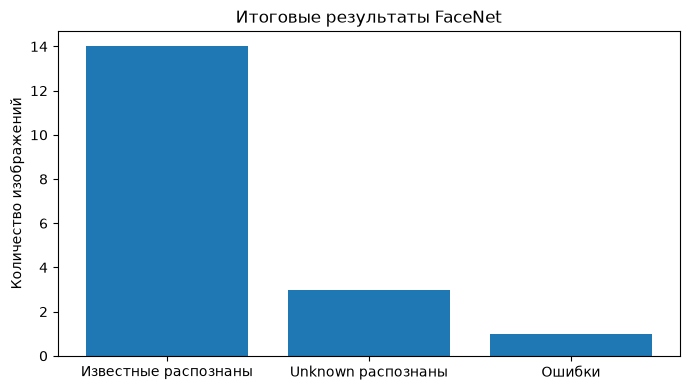


Итог:
Правильно известных: 14/15
Правильно Unknown: 3/3
Ошибок: 1


In [5]:
fill_face_db()

print("\nНачало тестирования")

test_all_images()

InsightFace

In [6]:
import cv2
import numpy as np

from insightface.app import FaceAnalysis


insight_app = FaceAnalysis(
    name="buffalo_l",
    providers=["CPUExecutionProvider"],
)

insight_app.prepare(
    ctx_id=-1,
    det_thresh=0.3,
    det_size=(640, 640),
)


def get_embedding_insightface(image_path):
    image = cv2.imread(image_path)

    if image is None:
        return None

    height, width = image.shape[:2]

    pad_h = height // 2
    pad_w = width // 2

    image = cv2.copyMakeBorder(
        image,
        pad_h,
        pad_h,
        pad_w,
        pad_w,
        cv2.BORDER_CONSTANT,
        value=(0, 0, 0),
    )

    image = cv2.resize(
        image,
        None,
        fx=3,
        fy=3,
        interpolation=cv2.INTER_CUBIC,
    )

    faces = insight_app.get(image)

    if len(faces) == 0:
        return None

    largest_face = max(
        faces,
        key=lambda face: (
            face.bbox[2] - face.bbox[0]
        ) * (
            face.bbox[3] - face.bbox[1]
        ),
    )

    return np.asarray(
        largest_face.embedding,
        dtype=np.float32,
    )

In [7]:
get_embedding = get_embedding_insightface

In [8]:
face_db = {}

/home/mlguest/miniforge3/envs/torch/lib/python3.12/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
/home/mlguest/miniforge3/envs/torch/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Abdullah Gul добавлен.
Adrien Brody добавлен.
Alejandro Toledo добавлен.
Alvaro Uribe добавлен.
Amelie Mauresmo добавлен.

Всего людей в базе: 5

Начало тестирования

Изображение: Abdullah_Gul_test_1.jpg
Abdullah Gul: 0.6133
Adrien Brody: -0.0453
Alejandro Toledo: -0.0606
Alvaro Uribe: -0.0540
Amelie Mauresmo: -0.0428

Найден человек: Abdullah Gul
Сходство: 0.6133

Изображение: Abdullah_Gul_test_2.jpg
Abdullah Gul: 0.5871
Adrien Brody: 0.0239
Alejandro Toledo: -0.0833
Alvaro Uribe: 0.0342
Amelie Mauresmo: -0.0549

Найден человек: Abdullah Gul
Сходство: 0.5871

Изображение: Abdullah_Gul_test_3.jpg
Abdullah Gul: 0.6822
Adrien Brody: -0.0281
Alejandro Toledo: -0.0900
Alvaro Uribe: -0.0673
Amelie Mauresmo: -0.0583

Найден человек: Abdullah Gul
Сходство: 0.6822

Изображение: Adrien_Brody_test_1.jpg
Abdullah Gul: -0.0222
Adrien Brody: 0.5785
Alejandro Toledo: -0.0499
Alvaro Uribe: 0.0956
Amelie Mauresmo: 0.0389

Найден человек: Adrien Brody
Сходство: 0.5785

Изображение: Adrien_Brody_test_2.

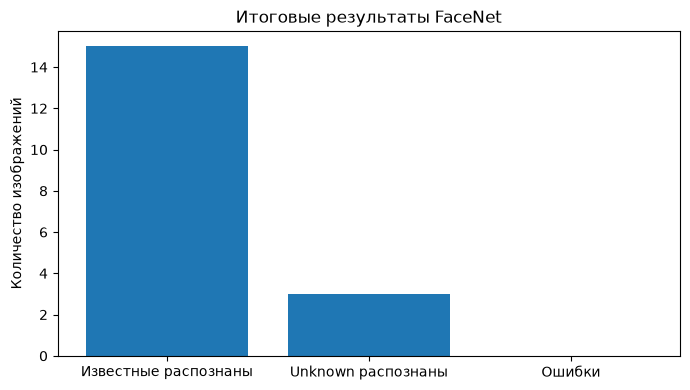


Итог:
Правильно известных: 15/15
Правильно Unknown: 3/3
Ошибок: 0


In [9]:
fill_face_db()

print("\nНачало тестирования")

test_all_images()